# GBM drift and volatility with Nested Sampling

One-year estimation windows, weekly log-returns, nested sampling posterior for annualized `mu` and `sigma`, plus a restricted `mu = 0` model for evidence comparison.

In [7]:
import sys
sys.path.append("../../src")

import matplotlib.pyplot as plt

from drift_vs_volatility_inference import drift_vs_vol_utils as dv

In [8]:
stock_name = 'AAPL'
start_year = 2000
end_year = 2023

return_window = 5

mu_min, mu_max = -2.0, 2.0
sigma_min, sigma_max = 0.01, 3.0

nlive = 300
dlogz = 0.05
random_seed = 123
example_year = 2023

In [9]:
prices = dv.download_prices(stock_name, start_year, end_year)
prices.head()

Date
2000-01-03    0.999442
2000-01-04    0.915179
2000-01-05    0.928571
2000-01-06    0.848214
2000-01-07    0.888393
Name: AAPL, dtype: float64

In [10]:
yearly_summary, yearly_results_full, yearly_results_mu0 = dv.run_nested_for_years(
    prices,
    range(start_year, end_year + 1),
    return_window=return_window,
    mu_min=mu_min, mu_max=mu_max,
    sigma_min=sigma_min, sigma_max=sigma_max,
    nlive=nlive, dlogz=dlogz, random_seed=random_seed,
)

Running 2000
Running 2001
Running 2002
Running 2003
Running 2004
Running 2005
Running 2006
Running 2007
Running 2008
Running 2009
Running 2010
Running 2011
Running 2012
Running 2013
Running 2014
Running 2015
Running 2016
Running 2017
Running 2018
Running 2019
Running 2020
Running 2021
Running 2022
Running 2023


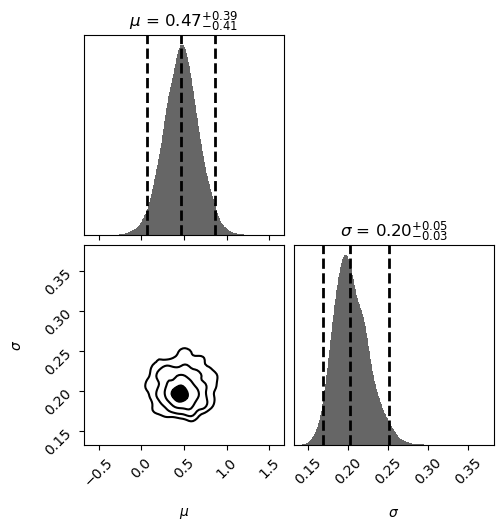

In [5]:
results_full = yearly_results_full[example_year]
results_mu0 = yearly_results_mu0[example_year]

fg, axs = dv.plot_corner(results_full)

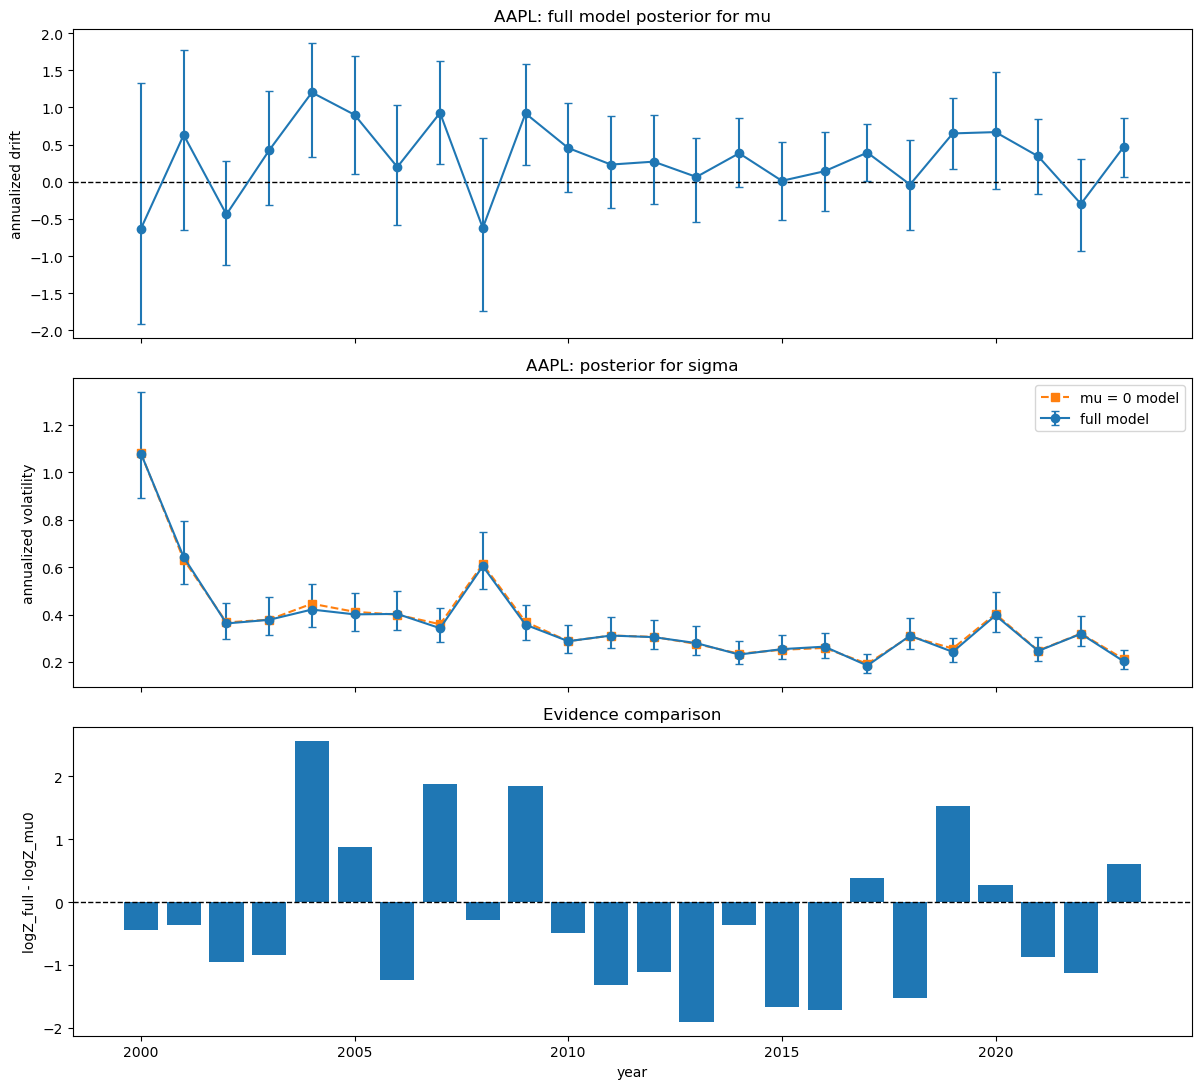

In [11]:
_ = dv.plot_drift_volatility_evidence(yearly_summary, stock_name)
plt.show()

## Pooled Bayes factor across stocks

Repeat the same per-year nested-sampling fit for a basket of large-cap stocks and pool the
resulting `logZ_full - logZ_mu0` values into one scatter (by year) and one histogram, one
dot per (ticker, year). If drift is generally indistinguishable from noise, most stock-years
should cluster near/below zero rather than showing consistent positive evidence for the
free-`mu` model.

In [12]:
tickers = [
    'AAPL', 'MSFT', 'AMZN', 'IBM', 'INTC', 'CSCO', 'ORCL', 'QCOM', 'TXN',
    'JPM', 'GS', 'WFC', 'C', 'BAC',
    'XOM', 'CVX',
    'JNJ', 'PFE', 'MRK', 'ABT',
    'PG', 'KO', 'WMT', 'COST', 'MCD',
    'DIS', 'HD', 'BA', 'CAT', 'MMM',
]

In [13]:
pooled_summary, pooled_results_full, pooled_results_mu0 = dv.run_nested_for_tickers(
    tickers,
    range(start_year, end_year + 1),
    return_window=return_window,
    mu_min=mu_min, mu_max=mu_max,
    sigma_min=sigma_min, sigma_max=sigma_max,
    nlive=nlive, dlogz=dlogz, random_seed=random_seed,
)

Running AAPL 2000
Running AAPL 2001
Running AAPL 2002
Running AAPL 2003
Running AAPL 2004
Running AAPL 2005
Running AAPL 2006
Running AAPL 2007
Running AAPL 2008
Running AAPL 2009
Running AAPL 2010
Running AAPL 2011
Running AAPL 2012
Running AAPL 2013
Running AAPL 2014
Running AAPL 2015
Running AAPL 2016
Running AAPL 2017
Running AAPL 2018
Running AAPL 2019
Running AAPL 2020
Running AAPL 2021
Running AAPL 2022
Running AAPL 2023
Running MSFT 2000
Running MSFT 2001
Running MSFT 2002
Running MSFT 2003
Running MSFT 2004
Running MSFT 2005
Running MSFT 2006
Running MSFT 2007
Running MSFT 2008
Running MSFT 2009
Running MSFT 2010
Running MSFT 2011
Running MSFT 2012
Running MSFT 2013
Running MSFT 2014
Running MSFT 2015
Running MSFT 2016
Running MSFT 2017
Running MSFT 2018
Running MSFT 2019
Running MSFT 2020
Running MSFT 2021
Running MSFT 2022
Running MSFT 2023
Running AMZN 2000
Running AMZN 2001
Running AMZN 2002
Running AMZN 2003
Running AMZN 2004
Running AMZN 2005
Running AMZN 2006
Running AM

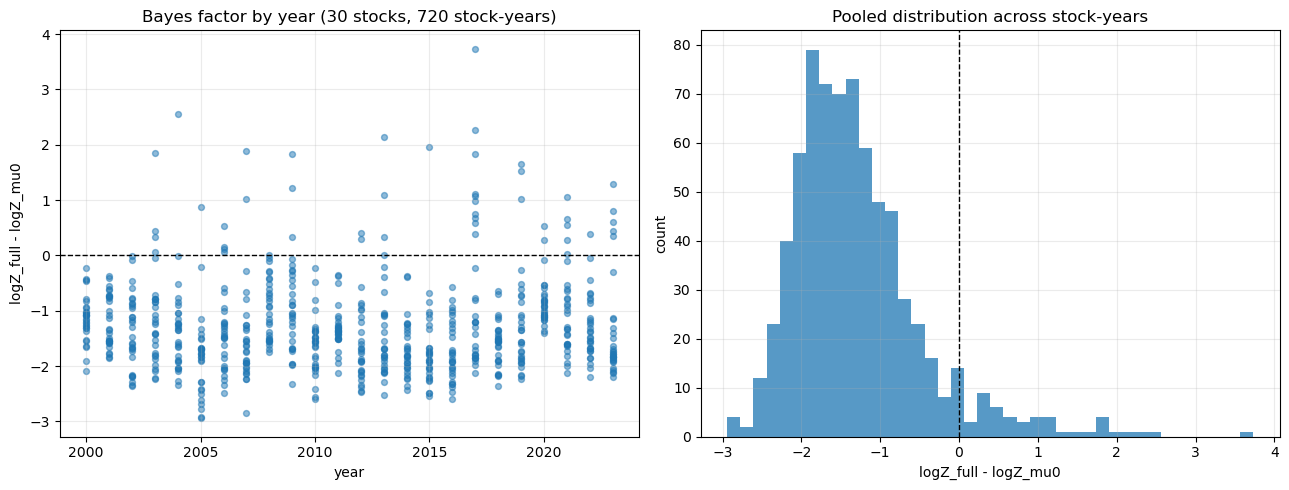

In [14]:
_ = dv.plot_bayes_factor_scatter_hist(pooled_summary)
plt.show()